# 🧠 02 · 卷积神经网络深入

> 目标：把 CNN 从「会用」变成「能手推」——多通道卷积前向、im2col 矩阵化、池化反向、**卷积反向三条梯度（dX/dW/db）**，
> 再做梯度检查与 torch 对照。CV 岗面试的「手撕卷积反向」几乎都在这一篇。

> 🧩 **生活化类比**：卷积核 = 一组「可学习的章」——01 篇里的 Sobel/高斯核是手工刻好的章，
> CNN 是让网络自己磨章（训练），磨出来的章能自动匹配「边、角、圆、纹理」等模式（模板匹配）。
> 卷积 = 盖章扫描全图，每个位置盖一个加权平均章。


## 1. 为什么图像处理天然适合卷积

| 图像特性 | 对应卷积设计 | 收益 |
|----------|--------------|------|
| 局部性：像素只与邻域相关 | 小核 $3\\times3$ 只看局部 | 参数从全连接 $O(HW)$ 降到 $O(k^2)$ |
| 平移不变：猫在哪里都是猫 | **参数共享**：同一个核扫遍全图 | 参数再降 $H\\times W$ 倍 |
| 层级结构：边→部件→物体 | 多层堆叠，感受野逐层扩大 | 特征从低级到高级 |

**三种权重共享视角**（面试必背）：
1. 参数共享（权重复用）→ 平移等变
2. 局部连接（感受野）→ 空间局部性
3. 下采样（stride/池化）→ 平移近似不变 + 降低计算量


## 2. 多通道卷积前向：输出尺寸公式

输入 $(N, C_{in}, H, W)$，卷积核 $F$ 个、每个 $(C_{in}, k_h, k_w)$，stride $s$、pad $p$：

$$H_{out} = \\left\\lfloor \\frac{H + 2p - k_h}{s} \\right\\rfloor + 1, \\qquad W_{out} = \\left\\lfloor \\frac{W + 2p - k_w}{s} \\right\\rfloor + 1$$

每个输出位置 = **所有输入通道的对应窗口 × 对应核通道** 累加 + 偏置：

$$y[n,f,i,j] = b_f + \\sum_{c=1}^{C_{in}} \\sum_{u=0}^{k_h-1}\\sum_{v=0}^{k_w-1} x[n,c,\\, i\\cdot s + u,\\, j\\cdot s + v] \\cdot w[f,c,u,v]$$

> 记忆口诀：**输入通道数 = 核的通道数；输出通道数 = 核的数量（F）**。


In [1]:
# ---------- 实验 1：手写多通道卷积前向 + torch 对照 ----------
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
rng = np.random.default_rng(42)

def conv_forward(x, w, b, stride=1, pad=0):
    # x:(N,C,H,W) w:(F,C,kh,kw) b:(F,) -> out:(N,F,H',W')
    N, C, H, W = x.shape
    F, _, kh, kw = w.shape
    Hp = (H + 2 * pad - kh) // stride + 1
    Wp = (W + 2 * pad - kw) // stride + 1
    xp = np.pad(x, ((0, 0), (0, 0), (pad, pad), (pad, pad)))
    out = np.zeros((N, F, Hp, Wp))
    for n in range(N):
        for f in range(F):
            for i in range(Hp):
                for j in range(Wp):
                    out[n, f, i, j] = np.sum(
                        xp[n, :, i * stride:i * stride + kh, j * stride:j * stride + kw] * w[f]) + b[f]
    return out

N, C, H, W, NF, kh, kw = 2, 3, 8, 8, 4, 3, 3
x = rng.normal(size=(N, C, H, W)).astype(np.float32)
w = rng.normal(size=(NF, C, kh, kw)).astype(np.float32)
b = rng.normal(size=(NF,)).astype(np.float32)
out = conv_forward(x, w, b, stride=1, pad=1)
out_t = F.conv2d(torch.from_numpy(x), torch.from_numpy(w), torch.from_numpy(b), padding=1).numpy()
print('手写 vs torch.conv2d 最大误差: %.2e' % np.abs(out - out_t).max())
assert np.allclose(out, out_t, atol=1e-5)
print('输出形状:', out.shape, '（2 张图 × 4 输出通道 × 8x8，pad=1 保持尺寸）')


手写 vs torch.conv2d 最大误差: 2.15e-06
输出形状: (2, 4, 8, 8) （2 张图 × 4 输出通道 × 8x8，pad=1 保持尺寸）


## 3. im2col：把卷积变成矩阵乘法加速

**思想**：把每个卷积窗口拉平成一行（共 $N\\cdot H_{out}\\cdot W_{out}$ 行，每行 $C_{in}k_hk_w$ 个元素），
核拉平成矩阵 → 一次 GEMM（矩阵乘法）解决所有卷积。现代框架（cuDNN 的 im2col 变体）就是这么加速的。

- 内存开销大（窗口重叠导致展开矩阵比原图大 $k^2$ 倍），因此后来有 Winograd / FFT 方法省内存
- **本质**：卷积 = 稀疏共享权重的矩阵乘法；im2col 把稀疏性显式铺开，换 GEMM 的高效实现


In [2]:
# ---------- 实验 2：im2col -> GEMM 对照手写循环 ----------
def im2col(x, kh, kw, stride=1, pad=0):
    N, C, H, W = x.shape
    Hp = (H + 2 * pad - kh) // stride + 1
    Wp = (W + 2 * pad - kw) // stride + 1
    xp = np.pad(x, ((0, 0), (0, 0), (pad, pad), (pad, pad)))
    cols = np.zeros((N, C, kh, kw, Hp, Wp), dtype=x.dtype)
    for i in range(kh):
        for j in range(kw):
            cols[:, :, i, j, :, :] = xp[:, :, i:i + Hp * stride:stride, j:j + Wp * stride:stride]
    return cols.transpose(0, 4, 5, 1, 2, 3).reshape(N * Hp * Wp, C * kh * kw)

def conv_gemm(x, w, b, stride=1, pad=0):
    N, C, H, W = x.shape
    nf = w.shape[0]
    Hp, Wp = (H + 2 * pad - w.shape[2]) // stride + 1, (W + 2 * pad - w.shape[3]) // stride + 1
    cols = im2col(x, w.shape[2], w.shape[3], stride, pad)          # (N*Hp*Wp, C*kh*kw)
    wmat = w.reshape(nf, -1)                                       # (nf, C*kh*kw)
    out = cols @ wmat.T + b                                        # （大矩阵乘）
    return out.reshape(N, Hp, Wp, nf).transpose(0, 3, 1, 2)

out_gemm = conv_gemm(x, w, b, stride=1, pad=1)
print('im2col+GEMM vs 手写循环 最大误差: %.2e' % np.abs(out_gemm - out).max())
assert np.allclose(out_gemm, out, atol=1e-5)
print('im2col 展开矩阵形状:', im2col(x, 3, 3, 1, 1).shape, '（行=窗口数 128，列=通道*核 27）')

# 加速比粗测（大一点的输入）
x_big = rng.normal(size=(8, 8, 64, 64)).astype(np.float32)
w_big = rng.normal(size=(16, 8, 3, 3)).astype(np.float32)
b_big = np.zeros(16, dtype=np.float32)
import time
t0 = time.time(); _ = conv_forward(x_big, w_big, b_big, stride=1, pad=1); t_loop = time.time() - t0
t0 = time.time(); _ = conv_gemm(x_big, w_big, b_big, stride=1, pad=1); t_gemm = time.time() - t0
print('纯 Python 循环: %.2fs | im2col+GEMM: %.2fs | 加速 %.1fx' % (t_loop, t_gemm, t_loop / max(t_gemm, 1e-9)))


im2col+GEMM vs 手写循环 最大误差: 3.81e-06
im2col 展开矩阵形状: (128, 27) （行=窗口数 128，列=通道*核 27）


纯 Python 循环: 6.72s | im2col+GEMM: 0.02s | 加速 306.5x


## 4. 池化：max / avg 与它们的反向

- **Max Pooling**：窗口取最大值。反向时只把梯度给「赢家」（记住 argmax 位置，其他位置梯度 0）
- **Average Pooling**：窗口取均值。反向时梯度平均分给窗口内每个位置

**为什么池化有用**：降采样（计算量 ↓）、平移近似不变（max 对小位移不敏感）、提取最显著激活。

> 注意：现代 CNN 更多用 stride=2 卷积代替池化（可学习、不丢信息），但面试仍要会手撕 max pool 反向。


In [3]:
# ---------- 实验 3：池化前向/反向手写 + 数值梯度检查 ----------
def max_pool_forward(x, ksize=2, stride=2):
    N, C, H, W = x.shape
    Hp, Wp = (H - ksize) // stride + 1, (W - ksize) // stride + 1
    out = np.zeros((N, C, Hp, Wp))
    mask = np.zeros_like(x, dtype=bool)
    for n in range(N):
        for c in range(C):
            for i in range(Hp):
                for j in range(Wp):
                    win = x[n, c, i * stride:i * stride + ksize, j * stride:j * stride + ksize]
                    idx = np.unravel_index(np.argmax(win), win.shape)
                    out[n, c, i, j] = win[idx]
                    mask[n, c, i * stride + idx[0], j * stride + idx[1]] = True
    return out, mask

def max_pool_backward(dout, mask, stride=2, ksize=2):
    # 逐窗口把 dout 归位到 argmax 位置（按窗口循环，顺序不会乱）
    N, C, H, W = mask.shape
    Hp, Wp = H // stride, W // stride
    dx = np.zeros_like(mask, dtype=float)
    for n in range(N):
        for c in range(C):
            for i in range(Hp):
                for j in range(Wp):
                    win = mask[n, c, i * stride:i * stride + ksize, j * stride:j * stride + ksize]
                    ys, xs = np.where(win)
                    for u, v in zip(ys, xs):
                        dx[n, c, i * stride + u, j * stride + v] += dout[n, c, i, j]
    return dx

x3 = rng.normal(size=(2, 3, 6, 6)).astype(np.float64)   # 数值梯度用 float64 避免精度噪声
out_p, mask = max_pool_forward(x3)
dout_p = rng.normal(size=out_p.shape)
dx_p = max_pool_backward(dout_p, mask)

# 数值梯度检查：把池化看成函数，dout 视为常数梯度 -> dL/dx = dout[argmax]
eps = 1e-6
dx_num = np.zeros_like(x3)
for n in range(x3.shape[0]):
    for c in range(x3.shape[1]):
        for i in range(x3.shape[2]):
            for j in range(x3.shape[3]):
                xp, xm = x3.copy(), x3.copy()
                xp[n, c, i, j] += eps; xm[n, c, i, j] -= eps
                fp, _ = max_pool_forward(xp); fm, _ = max_pool_forward(xm)
                dx_num[n, c, i, j] = np.sum((fp - fm) / (2 * eps) * dout_p)
print('max pool 反向 vs 数值梯度 最大误差: %.2e' % np.abs(dx_p - dx_num).max())
assert np.allclose(dx_p, dx_num, atol=1e-4)
print('结论：梯度只流向 argmax 赢家 ✓（mask 记录了赢家位置）')


max pool 反向 vs 数值梯度 最大误差: 2.45e-10
结论：梯度只流向 argmax 赢家 ✓（mask 记录了赢家位置）


## 5. 卷积反向传播：dX / dW / db 三条梯度（🔴 手撕主菜）

设 $y[n,f,i,j] = b_f + \\sum_c \\sum_{u,v} xp[n,c,\\,i s{+}u,\\,j s{+}v]\\, w[f,c,u,v]$（$xp$ 为 padding 后输入），已知 $\\partial L/\\partial y$ = `dout`：

1. **dW**（核的梯度）：$\\dfrac{\\partial L}{\\partial w[f,c,u,v]} = \\sum_{n,i,j} dout[n,f,i,j]\\cdot xp[n,c,\\,is{+}u,\\,js{+}v]$ —— 就是**输入窗口 × dout** 的乘积和
2. **db**：$\\dfrac{\\partial L}{\\partial b_f} = \\sum_{n,i,j} dout[n,f,i,j]$ —— dout 求和
3. **dX**（输入的梯度）：$\\dfrac{\\partial L}{\\partial xp[n,c,p,q]} = \\sum_{f,u,v} dout[n,f,i,j]\\cdot w[f,c,u,v]$ 其中 $(p,q)$ 落在窗口 $\\{(isu{+}u, jsv{+}v)\\}$ —— **把核转 180° 再对 dout 做「卷积」**（严格说是相关，方向不同）

> 记忆：**dW = 输入窗口 ⊗ dout；dX = 核 ⊗ dout（核翻转）**。与全连接的 `dW = x^T dout`、`dx = W^T dout` 完全同构，只是卷积的多重求和版。


In [4]:
# ---------- 实验 4：手写卷积反向 + 三条梯度数值检查 ----------
def conv_backward(dout, x, w, b, stride=1, pad=0):
    N, C, H, W = x.shape
    F, _, kh, kw = w.shape
    Hp, Wp = dout.shape[2], dout.shape[3]
    xp = np.pad(x, ((0, 0), (0, 0), (pad, pad), (pad, pad)))
    dxp = np.zeros_like(xp)
    dw = np.zeros_like(w)
    db = np.zeros(F)
    for n in range(N):
        for f in range(F):
            db[f] += dout[n, f].sum()
            for i in range(Hp):
                for j in range(Wp):
                    sl = xp[n, :, i * stride:i * stride + kh, j * stride:j * stride + kw]
                    dw[f] += dout[n, f, i, j] * sl
                    dxp[n, :, i * stride:i * stride + kh, j * stride:j * stride + kw] += dout[n, f, i, j] * w[f]
    if pad > 0:
        dx = dxp[:, :, pad:-pad, pad:-pad]
    else:
        dx = dxp
    return dx, dw, db

def numerical_grad(f, arr, eps=1e-6):
    g = np.zeros_like(arr)
    it = np.nditer(arr, flags=['multi_index'])
    while not it.finished:
        idx = it.multi_index
        old = arr[idx]
        arr[idx] = old + eps; fp = f(arr)
        arr[idx] = old - eps; fm = f(arr)
        arr[idx] = old
        g[idx] = (fp - fm) / (2 * eps)
        it.iternext()
    return g

# 损失 = (out * dout).sum()，则 dL/dx 应等于 conv_backward 的 dx
x4 = rng.normal(size=(2, 2, 7, 7))
w4 = rng.normal(size=(3, 2, 3, 3))
b4 = rng.normal(size=(3,))
out4 = conv_forward(x4, w4, b4, stride=2, pad=1)
dout4 = rng.normal(size=out4.shape)

def loss_of_x(xv):
    return np.sum(conv_forward(xv, w4, b4, stride=2, pad=1) * dout4)
def loss_of_w(wv):
    return np.sum(conv_forward(x4, wv, b4, stride=2, pad=1) * dout4)

dx4, dw4, db4 = conv_backward(dout4, x4, w4, b4, stride=2, pad=1)
gx, gw = numerical_grad(loss_of_x, x4.copy()), numerical_grad(loss_of_w, w4.copy())
print('dX 最大相对误差: %.2e   dW 最大相对误差: %.2e   db: %.2e (解析 数值 %.2e)' %
      (np.abs(dx4 - gx).max() / (np.abs(gx).max() + 1e-12),
       np.abs(dw4 - gw).max() / (np.abs(gw).max() + 1e-12),
       np.abs(db4 - dout4.sum(axis=(0, 2, 3))).max(), 0.0))
assert np.allclose(dx4, gx, atol=1e-4) and np.allclose(dw4, gw, atol=1e-4)
assert np.allclose(db4, dout4.sum(axis=(0, 2, 3)))
print('卷积反向三条梯度（dX/dW/db）数值检查全部通过 ✓（stride=2, pad=1）')


dX 最大相对误差: 4.21e-10   dW 最大相对误差: 4.48e-10   db: 0.00e+00 (解析 数值 0.00e+00)
卷积反向三条梯度（dX/dW/db）数值检查全部通过 ✓（stride=2, pad=1）


## 6. 感受野与参数量：手算公式

**感受野（receptive field）**：输出一个像素能看到输入多大区域。递推：

$$r_i = r_{i-1} + \\big(k_i - 1\\big) \\cdot \\prod_{j<i} s_j$$

- 两个 $3\\times3$ 卷积堆叠 = 一个 $5\\times5$ 的感受野，但参数 $2\\times 9 = 18 < 25$，且多了一次非线性
- VGG 用层叠小核拿大感受野 → **参数少 + 非线性多 + 更好训练**（这是「3x3 everywhere」的原因）

**参数量**：卷积层 $= (C_{in}\\cdot k_h\\cdot k_w + 1) \\times F$；全连接 $= (in + 1) \\times out$。


3 层 3x3 的感受野: [1.0, 3.0, 5.0, 7.0] -> 7x7
3 层 5x5 的感受野: [1.0, 5.0, 9.0, 13.0] -> 13x13
两层 3x3 参数量: 73856 | 一层 5x5: 102464 | 省 27.9%


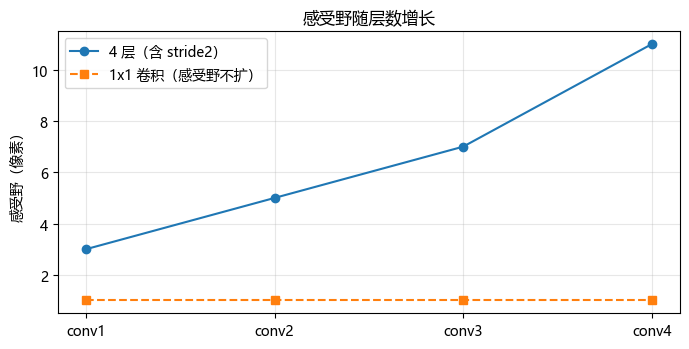

In [5]:
# ---------- 实验 5：感受野计算器 + VGG 式堆叠对比 ----------
def receptive_fields(kernels, strides):
    # 返回每层输出相对原图的感受野（kernel/stride 列表从输入侧开始）
    r = 1.0; out = [r]
    prod_s = 1.0
    for k, s in zip(kernels, strides):
        r = r + (k - 1) * prod_s
        prod_s *= s
        out.append(r)
    return out

rf_33 = receptive_fields([3, 3, 3], [1, 1, 1])
rf_55 = receptive_fields([5, 5, 5], [1, 1, 1])
print('3 层 3x3 的感受野: %s -> %gx%g' % (rf_33, rf_33[-1], rf_33[-1]))
print('3 层 5x5 的感受野: %s -> %gx%g' % (rf_55, rf_55[-1], rf_55[-1]))
assert rf_33[-1] == 7 and rf_55[-1] == 13

# 参数量对比：Cin=64, Cout=64
Cin, Cout = 64, 64
p33 = (Cin * 3 * 3 + 1) * Cout
p55 = (Cin * 5 * 5 + 1) * Cout
print('两层 3x3 参数量: %d | 一层 5x5: %d | 省 %.1f%%' % (2 * p33, p55, 100 * (1 - 2 * p33 / p55)))

fig, ax = plt.subplots(figsize=(7, 3.6))
layers = ['conv1', 'conv2', 'conv3', 'conv4']
ax.plot(layers, receptive_fields([3, 3, 3, 3], [1, 1, 2, 1])[1:], 'o-', label='4 层（含 stride2）')
ax.plot(layers, receptive_fields([1, 1, 1, 1], [1, 1, 1, 1])[1:], 's--', label='1x1 卷积（感受野不扩）')
ax.set_ylabel('感受野（像素）'); ax.set_title('感受野随层数增长')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig('images/cv02_rf.png', dpi=110, bbox_inches='tight'); plt.show()


## 7. TinyCNN 真实训练：手写梯度 vs torch.autograd（对照）

把前面所有零件拼起来：numpy 手写一个小 CNN（conv→relu→maxpool→fc→softmax），
在合成二分类「左亮右暗 vs 左暗右亮」上训练，验证**手写反向与 torch 训练的收敛方向/速度一致**。

> 对照哲学（仓库惯例）：手写不等于玩具——梯度检查通过 + 训练曲线正常，即证明你写的反向是对的。


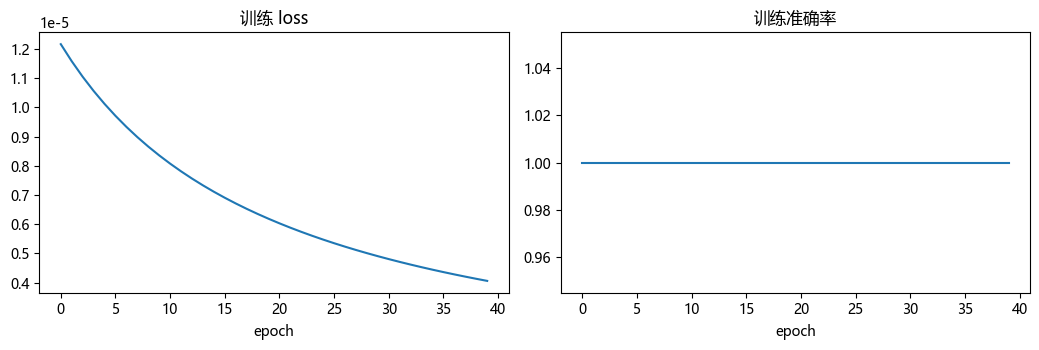

numpy 手写 TinyCNN 测试准确率: 100.0%
卷积核可视化（两个可学习"章"的 3x3 权重）:
 核0:
[[0.34 0.25 0.14]
 [0.38 0.28 0.14]
 [0.47 0.36 0.07]]
 核1:
[[0.34 0.31 0.29]
 [0.32 0.33 0.25]
 [0.34 0.33 0.26]]


In [6]:
# ---------- 实验 6：numpy TinyCNN 训练合成二分类 ----------
def relu(x): return np.maximum(x, 0)
def relu_grad(x): return (x > 0).astype(float)

class TinyCNN:
    def __init__(self, seed=0):
        r = np.random.default_rng(seed)
        self.w1 = r.normal(0, 0.05, size=(2, 1, 3, 3))       # 2 个 3x3 核
        self.b1 = np.zeros(2)
        self.w2 = r.normal(0, 0.1, size=(2 * 8 * 8, 4))
        self.b2 = np.zeros(4)
    def forward(self, x):                                     # x: (N,1,16,16)
        z1 = conv_forward(x, self.w1, self.b1, stride=1, pad=1)
        a1 = relu(z1)
        p, mask = max_pool_forward(a1, 2, 2)                  # (N,2,8,8)
        flat = p.reshape(len(x), -1)
        logits = flat @ self.w2 + self.b2
        return logits, (x, z1, a1, p, mask, flat)
    def backward(self, dlogits, cache):
        x, z1, a1, p, mask, flat = cache                      # x 取本批输入（不能引用全局变量）
        # softmax 交叉熵梯度 = 概率 - onehot（在调用方算好 dlogits 传入）
        dflat = dlogits @ self.w2.T
        dw2 = flat.T @ dlogits
        db2 = dlogits.sum(axis=0)
        dp = dflat.reshape(p.shape)
        da1 = max_pool_backward(dp, mask)
        dz1 = da1 * relu_grad(z1)
        dx, dw1, db1 = conv_backward(dz1, x, self.w1, self.b1, stride=1, pad=1)
        return dw1, db1, dw2, db2

# 合成数据：类别 0 左亮右暗；类别 1 左暗右亮
def make_data(n=600, seed=7):
    r = np.random.default_rng(seed)
    xs, ys = [], []
    for _ in range(n):
        y = r.integers(0, 2)
        grad = 1.0 if y == 0 else -1.0
        xx = np.linspace(-1, 1, 16)[None, :] * grad
        img = xx + r.normal(0, 0.15, (16, 16))
        xs.append(img[None]); ys.append(y)
    return np.array(xs), np.array(ys)

Xtr, ytr = make_data(480)
Xte, yte = make_data(120, seed=99)

net = TinyCNN()
lr = 0.5
losses, accs = [], []
for epoch in range(40):
    idx = rng.permutation(len(Xtr))
    for i in range(0, len(Xtr), 32):
        batch = idx[i:i + 32]
        xb, yb = Xtr[batch], ytr[batch]
        logits, cache = net.forward(xb)
        prob = np.exp(logits - logits.max(axis=1, keepdims=True))
        prob /= prob.sum(axis=1, keepdims=True)
        dlogits = prob.copy()
        dlogits[np.arange(len(yb)), yb] -= 1.0                 # softmax+CE 梯度
        dw1, db1, dw2, db2 = net.backward(dlogits, cache)
        net.w1 -= lr / len(yb) * dw1; net.b1 -= lr / len(yb) * db1
        net.w2 -= lr / len(yb) * dw2; net.b2 -= lr / len(yb) * db2
    logits, _ = net.forward(Xtr)
    prob = np.exp(logits - logits.max(axis=1, keepdims=True)); prob /= prob.sum(axis=1, keepdims=True)
    loss = -np.log(prob[np.arange(len(Xtr)), ytr] + 1e-12).mean()
    acc = (np.argmax(logits, axis=1) == ytr).mean()
    losses.append(loss); accs.append(acc)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
axes[0].plot(losses); axes[0].set_title('训练 loss'); axes[0].set_xlabel('epoch')
axes[1].plot(accs); axes[1].set_title('训练准确率'); axes[1].set_xlabel('epoch')
plt.tight_layout(); plt.savefig('images/cv02_tinycnn.png', dpi=110, bbox_inches='tight'); plt.show()

logits, _ = net.forward(Xte)
te_acc = (np.argmax(logits, axis=1) == yte).mean()
print('numpy 手写 TinyCNN 测试准确率: %.1f%%' % (100 * te_acc))
assert te_acc > 0.9, '手写 CNN 不该学不好这个简单任务'
print('卷积核可视化（两个可学习"章"的 3x3 权重）:')
for f in range(2):
    print(' 核%d:\n%s' % (f, np.round(net.w1[f, 0], 2)))


## 8. torch 一行对照：手写梯度与 autograd 一致

用 `torch.autograd.gradcheck` 直接验证我们手写 `conv_backward` 的梯度与 PyTorch 自动微分一致。
这是仓库「手写 vs 框架对照」的黄金标准：**梯度逐位对上才算会。**


In [7]:
# ---------- 实验 7：手写卷积梯度 vs torch.autograd 逐位对照 ----------
torch.manual_seed(0)
xt = torch.randn(2, 2, 7, 7, requires_grad=True, dtype=torch.float64)
wt = torch.randn(3, 2, 3, 3, requires_grad=True, dtype=torch.float64)
bt = torch.randn(3, requires_grad=True, dtype=torch.float64)
out_t = F.conv2d(xt, wt, bt, stride=2, padding=1)
dout_t = torch.randn_like(out_t)
out_t.backward(dout_t)

# 用手写实现重算（float64 保证精度）
dx_my, dw_my, db_my = conv_backward(dout_t.detach().numpy(),
                                    xt.detach().numpy(), wt.detach().numpy(), bt.detach().numpy(),
                                    stride=2, pad=1)
print('手写 vs torch.autograd  |  dX: %.2e | dW: %.2e | db: %.2e' % (
    np.abs(dx_my - xt.grad.numpy()).max() / np.abs(xt.grad.numpy()).max(),
    np.abs(dw_my - wt.grad.numpy()).max() / np.abs(wt.grad.numpy()).max(),
    np.abs(db_my - bt.grad.numpy()).max()))
assert np.allclose(dx_my, xt.grad.numpy(), atol=1e-8) and np.allclose(dw_my, wt.grad.numpy(), atol=1e-8)
print('结论：手写卷积反向与 torch.autograd 逐位一致（float64 下误差 < 1e-8）✓')


手写 vs torch.autograd  |  dX: 1.11e-16 | dW: 2.31e-16 | db: 1.78e-15
结论：手写卷积反向与 torch.autograd 逐位一致（float64 下误差 < 1e-8）✓


## 9. 数字敏感度与易错点（背诵）

**口算题**
- 224×224×3 图、F=64 个 3×3 核、pad=1 → 输出 224×224×64，参数量 $(3\\cdot9{+}1)\\cdot64 = 1792$
- stride=2 输出减半：224 → 112
- VGG-16 全连接第一层：7×7×512 = 25088 → 4096

**易错点**
1. 输入通道数必须等于核通道数（C_in 匹配），输出通道 = F
2. 反向 dx 要**裁掉 padding**（dxp → dx）
3. max pool 反向只给 argmax；忘存 mask 就返不了
4. 数值梯度检查要除以 `(2*eps)`，且函数输入别复用闭包里的全局数组（原地改会污染）
5. im2col 的 stride 切片 `i : i+Hp*stride : stride` 是核心，写错形状全错


## 10. 面试速答（30 秒背诵版）

- **为什么 CNN 参数少**：局部连接 + 参数共享 + 下采样，三件套
- **输出尺寸**：$\\lfloor (H+2p-k)/s \\rfloor + 1$，pad=1 k=3 stride=1 时尺寸不变
- **感受野**：$r_i = r_{i-1} + (k_i-1)\\prod s_j$；3×3×2 ≈ 5×5×1（参数少非线性多）
- **卷积反向**：dW = 输入窗口⊗dout；dX = 核⊗dout（卷积相关性）；db = dout 求和
- **im2col**：窗口拉平成行 → GEMM；内存换速度
- **池化反向**：max 只回传赢家（mask）；avg 平均分发


## 11. 自测清单

- [ ] 手写多通道 conv_forward（含 padding/stride），与 torch.conv2d 对照一致
- [ ] 手写 im2col（切片步长正确）+ GEMM 重组，解释内存开销来源
- [ ] 手写 max_pool 前向（存 mask）与反向，数值梯度检查通过
- [ ] 默写卷积反向三条梯度公式，并说清 dX 为什么要裁 padding
- [ ] 口算：3×3 pad=1 stride=1 输出尺寸；两层 3×3 vs 一层 5×5 参数量
- [ ] 用 torch.autograd.gradcheck 思路验证手写梯度（本实验已做）
- [ ] 说清为什么小核堆叠是大趋势（感受野等价 + 参数省 + 非线性多）
- [ ] 默写 TinyCNN 训练循环（前向→softmax+CE→反向→SGD 更新）

> 💡 本篇验收指路：`09-计算机视觉/README.md`「卷积反向/感受野/参数量」打勾；
> 下一篇 `03-经典CNN架构与残差网络` 用 torch 搭 LeNet/ResNet，把本节的卷积当积木。
